# Trabajo Final de Máster (1era parte)

Daniel Núñez Vargas

Este notebook documenta de manera integral el proceso de construcción del score de riesgo, abarcando desde el preprocesamiento y limpieza de datos hasta la implementación del modelo final. Se presenta una metodología sistemática que incluye todas las etapas de transformación y depuración aplicadas a los conjuntos de datos originales.

Una característica fundamental de este análisis es la integración de múltiples fuentes de información heterogéneas, las cuales fueron consolidadas mediante técnicas de vinculación de datos para generar un dataset enriquecido. Esta estrategia permite capturar dimensiones complementarias del fenómeno estudiado, proporcionando una perspectiva más holística y robusta para el desarrollo del modelo de riesgo.  Las fuentes de datos específicas se documentan progresivamente a medida que son introducidas en el flujo analítico, manteniendo la trazabilidad completa del proceso y facilitando la reproducibilidad del análisis.


In [1]:
# Se cargan todos los paquetes necesarios

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as patches
import seaborn as sns
from scipy.interpolate import make_interp_spline
import pandas as pd
import numpy as np
import re
import os
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point, box
from shapely import wkt
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
import holidays
from tqdm import tqdm
import seaborn as sns
import jenkspy
from Funciones import * # Script donde se han incluido variedad de funciones personalizadas


In [39]:
# Carga de los datos https://opendataphilly.org/datasets/crime-incidents/
gdf_2025 = gpd.read_file("../Input/Incidents2025/Incidents_2025.shp") # Cartografía de los datos 2025
gdf_2024 = gpd.read_file("../Input/Incidents2024/Incidents_2024.shp") # Cartografía de los datos 2024
# Se procede a realizar un merge entre ambos conjuntos
gdf = gpd.GeoDataFrame(pd.concat([gdf_2024, gdf_2025], ignore_index=True), crs=gdf_2024.crs)
# Reprojectar a Web Mercator si no está ya
gdf = gdf.to_crs(epsg=3857)

# Se eliminan las bases originales para liberar memoria
del gdf_2025
del gdf_2024

## Descripción de los datos

Las variables que componen estos datos son:

- **the_geom**: Geometría espacial en formato WKT (Well-Known Text) - representa la ubicación geográfica exacta del incidente
- **cartodb_id**: Identificador único secuencial asignado por CartoDB para cada registro
- **the_geom_webmercator**: Geometría espacial en proyección Web Mercator - formato optimizado para mapas web
- **objectid**: Identificador único del objeto en la base de datos original del sistema policial
- **dc_dist**: Código del distrito policial (1-25) - división administrativa de la policía de Filadelfia
- **psa**: Área de Servicio Policial (Police Service Area) - subdivisión más pequeña dentro de cada distrito
- **dispatch_date_time**: Fecha y hora completa cuando se despachó la llamada de emergencia
- **dispatch_date**: Solo la fecha cuando se despachó la llamada (formato YYYY-MM-DD)
- **dispatch_time**: Solo la hora cuando se despachó la llamada (formato HH:MM:SS)
- **hour**: Hora del día extraída de dispatch_time (0-23) - útil para análisis temporal
- **dc_key**: Clave única del incidente en el sistema de despacho - combina fecha y número secuencial
- **location_block**: Descripción textual de la cuadra donde ocurrió el incidente (ej: "1100 BLOCK S 4TH ST")
- **ucr_general**: Código numérico del Uniform Crime Reporting (UCR) - sistema estándar de clasificación de delitos
- **text_general_code**: Descripción textual del tipo de delito según clasificación UCR
- **point_x**: Coordenada X (longitud) en sistema de coordenadas de Pensilvania
- **point_y**: Coordenada Y (latitud) en sistema de coordenadas de Pensilvania
- **lat**: Latitud en grados decimales (WGS84) - coordenada geográfica estándar
- **lng**: Longitud en grados decimales (WGS84) - coordenada geográfica estándar

Hay varias variables que para efectos del análisis no resultan imporantes, como los identificadores únicos **cartodb_id**, **objectid** y **dc_key**. Además, hay algunas otras que explican lo mismo, como lo son las **dispatch_date_time** con **dispatch_date** y **hour**. Asimismo, **point_x** y **point_y** que dan las coordenadas de acuerdo al formato local. Otras variables que a priori se pueden omitir serán **the_geom** y **the_geom_webmercartor**, ya que se le dará prioridad al uso de latitud y longitud en formato estándar (WGS84) para identificación geoespacial de patrones.

Haciendo un plot sobre la cartografía consultada:

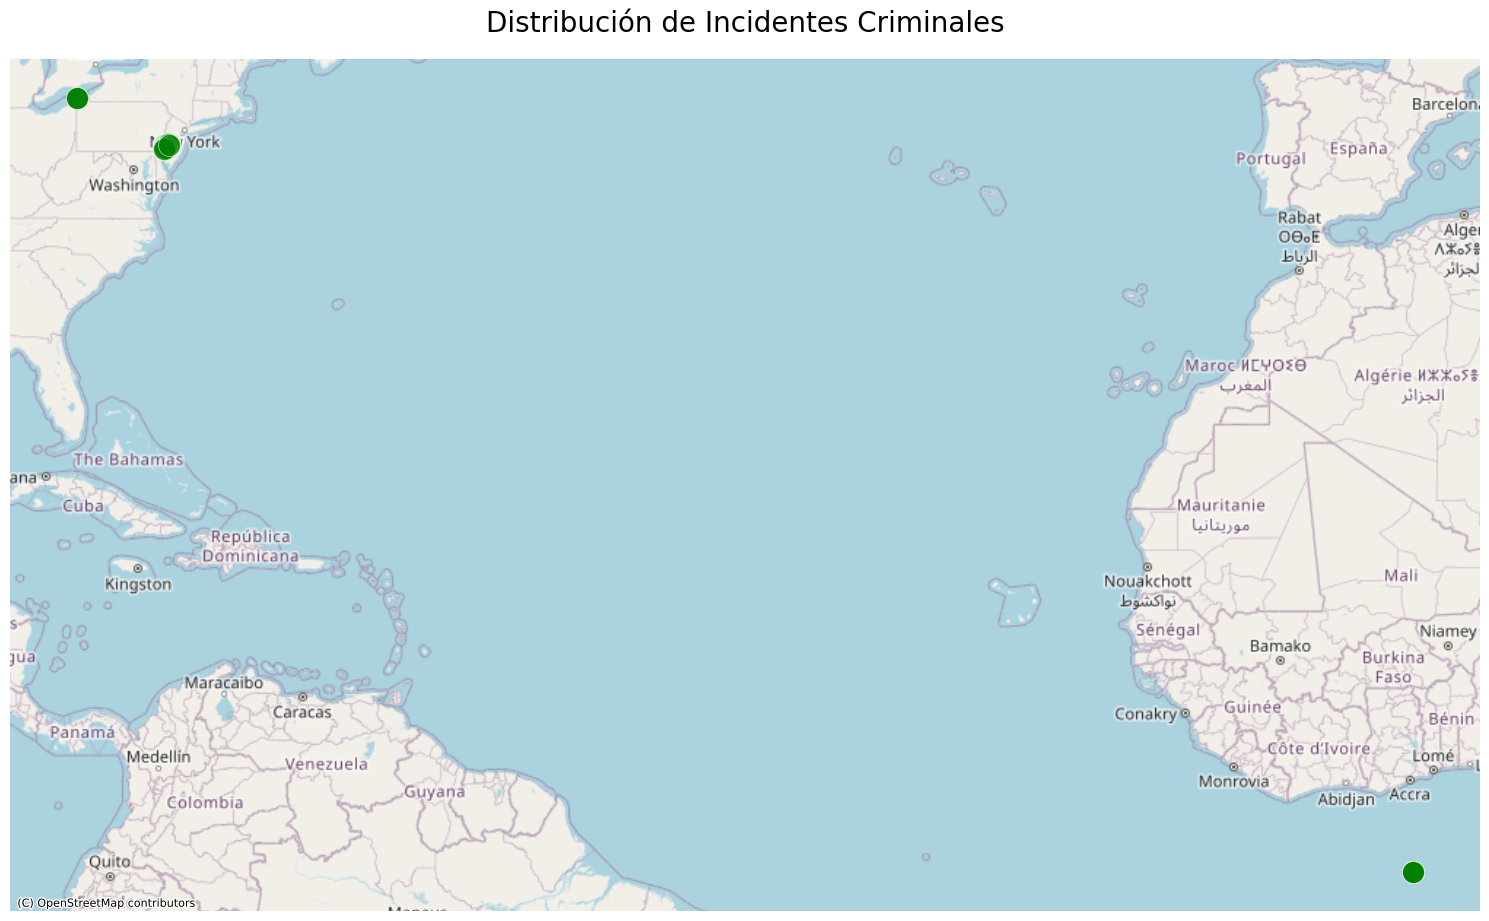

In [40]:
plt.style.use('default')
fig, ax = plt.subplots(figsize=(15, 12))

gdf.plot(ax=ax, 
         color='green',           
         edgecolor='white',         
         linewidth=0.5,           
         alpha=0.7,        
         markersize=250)            

ctx.add_basemap(ax, 
                source=ctx.providers.OpenStreetMap.Mapnik,  # Mapa oscuro elegante
                zoom='auto')

# Título
plt.title("Distribución de Incidentes Criminales", 
          fontsize=20, 
          pad=20,
          color='black')

# Quitar ejes y hacer el fondo transparente
ax.set_axis_off()
fig.patch.set_facecolor('white')

# Ajustar los márgenes
plt.tight_layout()
plt.show()

Primero observamos que existen dos nubes de punto muy distantes de Filadelfia; muy probablemente son valores vacíos/atípicos que deberán ser tratados correctamente. Se procederá a convertir dichas coordenadas en NA para posteriormente ser imputadas basándonos en la ubicación de crímenes que ocurrieron en bloques cercanos.

In [41]:
# 1. Convertir a DataFrame
df_pandas = gdf.copy()
df_pandas['longitude'] = gdf.geometry.x
df_pandas['latitude'] = gdf.geometry.y
df_pandas = df_pandas.drop(columns=['geometry'])

In [42]:
# Define límites aproximados para Filadelfia en EPSG:3857
min_lon, max_lon = -8380000, -8310000
min_lat, max_lat = 4845000, 4890000
# Define la condición de outliers (fuera de los límites aproximados de Filadelfia)
condicion = (
    (df_pandas['longitude'] < min_lon) | (df_pandas['longitude'] > max_lon) |
    (df_pandas['latitude'] < min_lat) | (df_pandas['latitude'] > max_lat)
)
# Asignar NA a los registros que cumplan la condición
df_pandas.loc[condicion, ['longitude', 'latitude']] = np.nan
print(f"Registros modificados: {condicion.sum()}")

Registros modificados: 9


Dado que las coordenadas geográficas serán variables claves dentro del modelo, lo primero será la forma de tratarlas en caso en donde no hayan datos. Lo primero que se nota es que se identificaron 9899 registros que no presentan información sobre latitud o longitud. El primer acercamiento que tendremos será identificar estas observaciones y analizar sus similitudes con observaciones que sí tengan información sobre sus coordenadas.

In [43]:
# Se filtran aquellas observaciones que no tienen algunas de las dos coordenadas
df_nan = df_pandas[(df_pandas['latitude'].isna()) | (df_pandas['longitude'].isna())]
print("Cantidad de registros con missing values en alguna de las dos coordenadas:", len(df_nan))

Cantidad de registros con missing values en alguna de las dos coordenadas: 9899


In [44]:
# Ahora se extren las ubicaciones de manera única
location_blocks_nan = df_nan['location_b'].unique()

# Se toma como ejmplo el bloque 1900 BLOCK S CHRISTOPHER COLUMBUS BLVD para ilustrar la problemática
df_temp_1 = df_pandas[df_pandas['location_b']== '1900 BLOCK S CHRISTOPHER COLUMBUS BLV'].head(1)
df_temp_2 = df_pandas[df_pandas['location_b']== '1900 BLOCK S CHRISTOPHER COLUMBUS BLVD'].head(1)

print(pd.concat([df_temp_1, df_temp_2])[['location_b', 'point_y', 'point_x']])

                                    location_b    point_y    point_x
160522   1900 BLOCK S CHRISTOPHER COLUMBUS BLV        NaN        NaN
2025    1900 BLOCK S CHRISTOPHER COLUMBUS BLVD  39.922182 -75.142376


Notamos algo interesante ya que para un registro sí se tienen coordenadas de ese bloque mientras que para otro no, siendo la única diferencia entre registros la palabra "BLVD". Este compartamiento se repite para miles de observaciones, por lo que el primer paso será depurar la variable location_block, ya que esta nos permitirá realizar la imputación basándonos en el bloque en el ocurrió el delito. Para ello se creó la función normalize_block_name, que se encarga de utilzar técnicas de text mining para homologar los nombres y se aplica para todos los registros.

In [45]:
# Se aplica la función
df_pandas['location_block_normalized'] = df_pandas['location_b'].apply(normalize_block_name)

Ahora examinamos la cardinalidad de las variables latitud y longitud por bloque, para intentar distinguir si existen varias set de coordenadas asociadas a cada bloque.

In [46]:
coordinates_info_by_block = (df_pandas.groupby(['location_block_normalized']).agg(
    unique_latitudes=('latitude', 'nunique'),
    unique_longitudes=('longitude', 'nunique')
)).sort_values(by = 'unique_latitudes', ascending=False)
print(coordinates_info_by_block.head(5))

                           unique_latitudes  unique_longitudes
location_block_normalized                                     
FRANKFORD AVE                            98                 98
GERMANTOWN AVE                           97                 98
N BROAD ST                               90                 90
4000 BLOCK LANCASTER AVE                 82                 82
3100 BLOCK KENSINGTON AVE                73                 73


Como se observa en el cuadro anterior, un bloque puede tener más de una latitud y longitud. Esto sucede porque los bloques fueron redondeados al bloque de cien más cercano según la fuente de los datos. Tomemos el caso que presenta mayor cardinalidad para efectos de la explicación, el cual es **FRANKFORD AVE**. 

Si tomamos todas las longitudes y latitudes para este bloque, y se calcula el mínimo y el máximo nos damos cuenta que realmente todos lo registros en latitud están entre los 39.9645° y los 40.0638°. De manera análoga para longitud, ubicando todos los crímenes entre los -75.1344° y los -75.9856°.

In [47]:
df_temp = df_pandas[df_pandas['location_block_normalized'] == 'FRANKFORD AVE'][['location_block_normalized', 'point_y', 'point_x']]

print(df_temp['point_y'].quantile([0,1]).round(4))
print(df_temp['point_x'].quantile([0,1]).round(4))

0.0    39.9645
1.0    40.0638
Name: point_y, dtype: float64
0.0   -75.1344
1.0   -74.9856
Name: point_x, dtype: float64


Aunque existan diferentes longitudes y latitudes para un mismo bloque, este hallazgo lo que nos indica es que la diferencia en términos de grados es marginal por lo que para efectos de hacer imputación para aquellos registros que no tienen coordenadas, se tomará el primer set de coordenadas encontradas para dicho bloque. 

Esto tiene una razón de ser, y es que como se verá más adelante, para nuestro objetivo de eventualmente intentar predecir el nivel de riesgo en la zona, se utilizarán las geometrías asociadas a los polígonos de las ZCTA (Zip Code Tabulation Area). Esto es una representación geográfica aproximada de las áreas de servicio de códigos postales, creada por la Oficina de Censos de los Estados Unidos para fines estadísticos y mapeo de poblaciones.

In [48]:
# Extraemos los registros que NO tienen missing en sus coordenadas
df_non_nan_unique = (
    df_pandas[~(df_pandas['latitude'].isna() | df_pandas['longitude'].isna())]
    .sort_values('dispatch_d')  # opcional: para priorizar por fecha
    .drop_duplicates(subset='location_block_normalized', keep='first')
    [['location_block_normalized', 'latitude', 'longitude']]
)
# Se filtran aquellas observaciones que SÍ tienen missing en sus coordenadas
df_nan_clean = df_pandas[(df_pandas['latitude'].isna()) | (df_pandas['longitude'].isna())].drop(['latitude', 'longitude'], axis=1)
# Se procede a hacer el leftjoin entre ambos datasets utilizando como llave la variable de location_block_normalized, que corresponde al bloque normalizado con técnicas de text mining
df_nan_join = df_nan_clean.merge(
    df_non_nan_unique,
    on='location_block_normalized',
    how='left',
)

La cantidad de registros que aún se mantienen como nulos son:

In [49]:
print("Cantidad de registros que aún no se mantienen como missing:", df_nan_join['latitude'].isnull().sum())

Cantidad de registros que aún no se mantienen como missing: 960


Así que de los 9899 registros que en un inicio tenía sus coordenadas como valores vacíos, mediante esta técnica de imputación se logró reducir ese número a tan solo 960 registros. Dentro de estos encontramos casos como el de **6500 BLOCK HAVERFORD** el cual no tiene ninguna coicidencia cercana respecto a los otros bloques. 

In [50]:
# Se filtran aquellas observaciones que desde un inicio no tenias las coordenadas vacias
df_non_nan = df_pandas[~(df_pandas['latitude'].isna() | df_pandas['longitude'].isna())]

Imputar el resto de observaciones implica un análisis individualizado, sin embargo, es más el costo en el que se incurriría que el simple hecho de descartarlas para efectos del trabajo propuesto, ya que solo representan un 0.40% del número total de registros.

In [51]:
# Se filtran las variables de interes 
df_nan_filled = df_nan_join[['latitude', 'longitude', 'hour', 'dispatch_1', 'dc_dist', 'psa', 'ucr_genera', 'text_gener', 'location_b', 'location_block_normalized']]
# Se unen ambos dataframes (El original que no tenías las coordenadas en cero + observaciones imputadas)
df_non_nan_gps = pd.concat([df_non_nan, df_nan_filled]).dropna(subset=['latitude', 'longitude'])
# Se filtran aquellas observaciones que aún se mantienen como vacías
df_still_nan = df_nan_join[df_nan_join['latitude'].isna() | df_nan_join['longitude'].isna()]
print("Los 960 registros que aún se mantienen como missing corresponde a un", round(len(df_still_nan)/len(df_non_nan_gps)*100,2),"% del numero total de registros")

Los 960 registros que aún se mantienen como missing corresponde a un 0.4 % del numero total de registros


In [52]:
# Lista de variables a borrar para mantener limpio el ambiente
variables_a_borrar = ['coordinates_info_by_block', 'df', 'df_pandas', 'df_nan', 
                      'df_nan_clean', 'df_nan_filled', 'df_nan_join', 'df_non_nan', 
                      'df_non_nan_unique', 'df_temp_1',  'df_temp_2', 'condicion', 
                      'location_blocks_nan', 
                      'max_lon', 'min_lon', 'min_lat', 'max_lat', 'df_still_nan', 
                      'df_temp', 'location_blocks_nan' 'var', 'variables_a_borrar', 'var_name']
for var_name in variables_a_borrar:
   if var_name in globals():
       del globals()[var_name]

# Se descartan varias variables que no aportan valor agregado
df_non_nan_gps = df_non_nan_gps.drop(['objectid', 'dispatch_d', 'dispatch_t', 'dc_key', 'location_b', 'point_x',
       'point_y'], axis=1)

In [53]:
# El resultado se convierte en un objeto de tipo geo dataframe
geometry = [Point(lon, lat) for lon, lat in zip(df_non_nan_gps['longitude'], df_non_nan_gps['latitude'])]

gdf_fill_na = gpd.GeoDataFrame(
    df_non_nan_gps.drop(columns=['longitude', 'latitude']), 
    geometry=geometry,
    crs=gdf.crs 
)

Ahora que se tiene una base de datos mucho más limpia, se procede a graficar en el mapa de Filadelfia, todas las diferentes ubicaciones en donde se han reportado crímenes. Adicionalmente, una mapa de calor que identifica las zonas en donde mayores crímenes suceden.

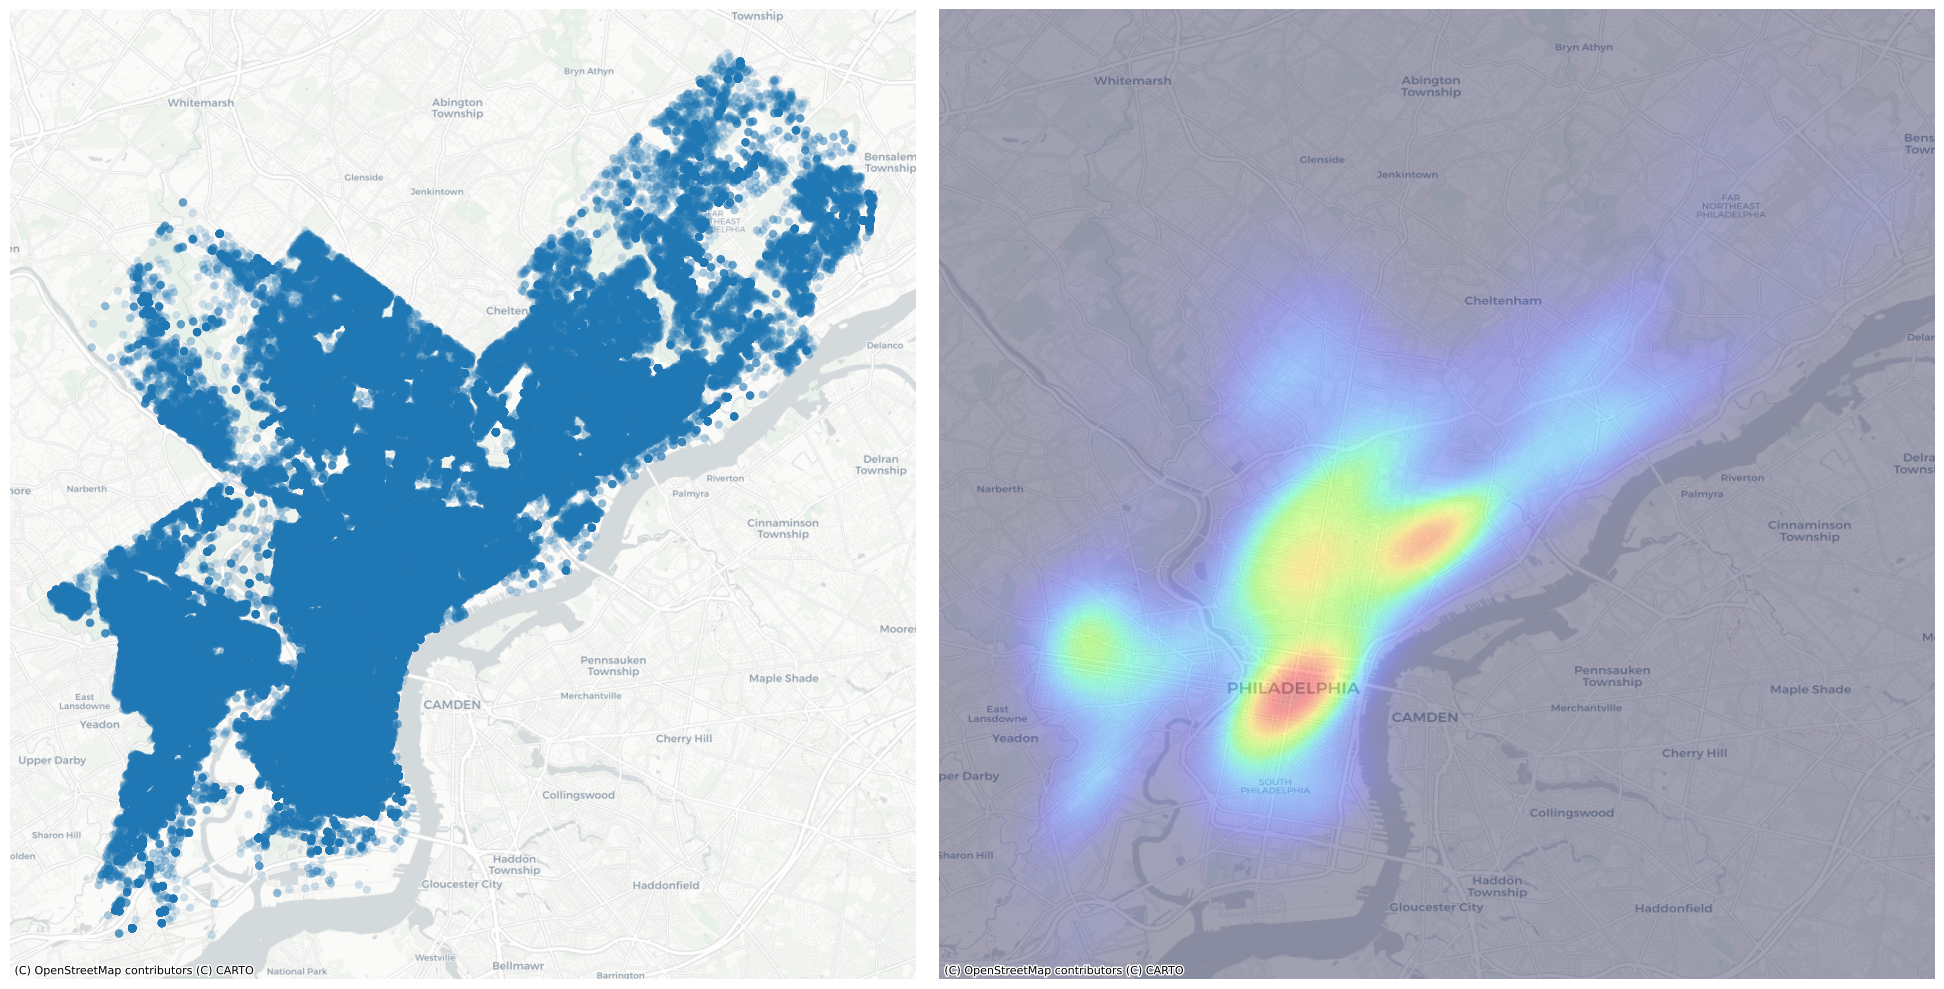

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))

# Primer gráfico (puntos sobre mapa base)
gdf_fill_na.plot(ax=axes[0], edgecolor='none', alpha=0.2)
ctx.add_basemap(axes[0], source=ctx.providers.CartoDB.Positron, crs=gdf_fill_na.crs)
axes[0].axis("off")
# axes[0].set_title("Incidentes sobre mapa base", fontsize=14)

# Segundo gráfico (heatmap con solo 100 registros)
create_heatmap(gdf_fill_na, ax=axes[1], show_grid=False)
# axes[1].set_title("Mapa de Calor (100 registros)", fontsize=14)

plt.tight_layout()
plt.show()

El siguiente paso sería separar nuestros datos entre el train y test, pero para esto hay que tener dos puntos presentes:

- Este es un problema espacial, pero también temporal, dado que estamos analizando el momento en el que los crímenes fueron cometidos. Por ello, este split también deberá ser temporal, es decir, utilizar los registros más antiguas para entrenar y los más recientes para realizar el test.

- El score debe ser creado utilizando solo los registros de la base de entrenamiento, de otra forma, se estarían utilizando datos del futuro para construir dicho indicador, introduciendo data leakage al modelo.

In [57]:
# Se renombran las variables para mayor interpretabilidad
gdf = gdf_fill_na.rename(
    columns={
        'dispatch_1': 'dispatch_date',
        'ucr_genera': 'crime_code',
        'text_gener': 'crime_description',
        'objectid' : 'crime_id'
        }).sort_values(by=['dispatch_date', 'hour'], ascending=[True, True])

Se realiza el split de tal manera que el modelo entrene con toda la información generada en el 2024 y haya un ciclo calendario completo. Posteriormente se usarán meses del 2025 para validar, en este caso, para que se conservara la proporción 70/30, se utilizará la información de los primeros 5 meses.

In [58]:
# Se filtra la información de tal manera que el split creado sea el más cercano a un 70/30
gdf = gdf[(gdf['dispatch_date'] < '2025-06-01')]
df_train = gdf[gdf['dispatch_date'] < '2025-01-01']
df_test = gdf[(gdf['dispatch_date'] >= '2025-01-01') & (gdf['dispatch_date'] < '2025-06-01')]

# Se guardan los resultados por trazabilidad
# df_train.to_file("../Input/ModelingDatasets/Train/df_train_without_score_PointCoordinates.shp")
# df_test.to_file("../Input/ModelingDatasets/Test/df_test_without_score_PointCoordinates.shp")

A nivel de porcentaje, los splits quedaron de la siguiente forma:

In [59]:
print(f"Training set: {round(len(df_train)/len(gdf)*100,2)} %")
print(f"Test set: {round((len(df_test))/len(gdf)*100,2)} %")

Training set: 73.16 %
Test set: 26.84 %


## Indicador de Riesgo

In [2]:
# Se recomienda limpiar el enviroment y comenzar a ejecutar a partir de este punto
df_train = cleanDataframe2(gpd.read_file("../Input/ModelingDatasets/Train/df_train_without_score_PointCoordinates.shp"))
# df_train = df_train.copy()

Elaborar un indicador de riesgo con solamente estadísticas frecuentistas generaría un sesgo muy grande a las zonas más pobladas.

La intención es elaborar este indicador pero fijandonos en más variables de interés, como por ejemplo periodo del día, día de la semana, temporada del año, así también como la relación que existe entre la cantidad de crímenes graves y no graves.

Para ello primero se necesitan extraer todos esos datos de las actuales variables.

### Variables temporales

Se procede a extaer las siguientes variables:

- Periodo del día: Se segmentará en 3 periodos diferentes

    - Mañana: 6AM - 12PM
    - Tarde: 12PM - 8PM
    - Noche: 8PM - 6AM

- Día de la semana
- Semana del año
- Mes
- Temporada (Invierno, Primavera, Verano, Otoño)
- Se incorporará un identificador para saber si la fecha fue un holiday en Estados Unidos


In [3]:
# Se declaran las condiciones para segregar el dia por periodos
condiciones = [
    (df_train['hour'] >= 6 ) & (df_train['hour'] < 12 ),
    (df_train['hour'] >= 12 ) & (df_train['hour'] < 20 ),
    (df_train['hour'] < 6 ) | (df_train['hour'] >= 20),

]
# Se definen los periodos posibles
periodOfTheDay = ['Morning', 'Afternoon', 'Night']
# Se define el periodo con base en la columna 'hour'
df_train["time_of_day"] = np.select(condiciones, periodOfTheDay, default='Unknown')
# Convertimos fecha en objeto datetime
df_train['date'] = pd.to_datetime(df_train['date'])
# Extraemos el día de la semana
df_train['day_of_week'] = df_train['date'].dt.day_name()
# Extraemos semana del año
df_train['week_of_year'] = df_train['date'].dt.isocalendar().week
# Extraemos mes
df_train['month'] = df_train['date'].dt.month_name()
# Extraemos estación del año
df_train['season'] = df_train['date'].apply(obtener_estacion)
# Se definen los feriados en Filadelfia
us_holidays = holidays.UnitedStates(years=df_train['date'].dt.year.unique(),state='PA')
# Crear la nueva columna que marca si es feriado o no
df_train['is_holiday'] = df_train['date'].dt.date.isin(us_holidays)

Para evidenciar si existe cierto patrón temporal en la indidencia de los crímenes, se procede a graficar la distribución de la variable 'Hour'

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23320\2910075193.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdYlGn_r')


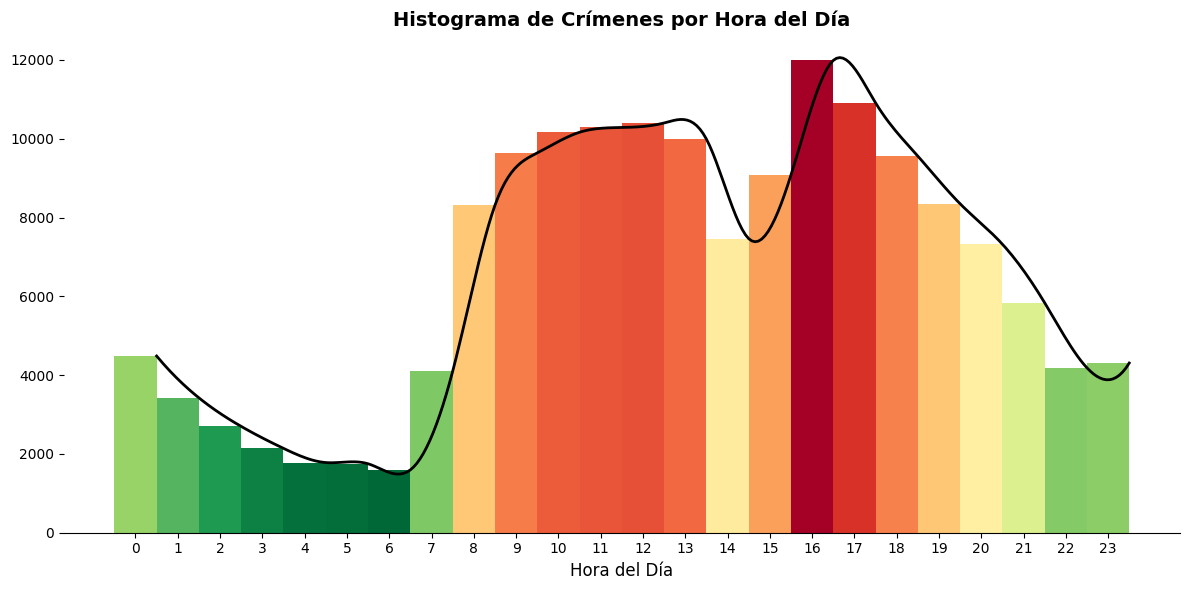

In [4]:
# Extraer las horas
hours = df_train['hour']

# Calcular frecuencias para colorear
counts, bins = np.histogram(hours, bins=range(25))  # 24 bins: 0–24
norm = mcolors.Normalize(vmin=counts.min(), vmax=counts.max())
cmap = cm.get_cmap('RdYlGn_r')
colors = [cmap(norm(v)) for v in counts]

# Crear gráfico
plt.figure(figsize=(12, 6))
for i in range(len(counts)):
    plt.bar(bins[i], counts[i], width=1, color=colors[i], edgecolor="none")

x = bins[:-1] + 0.5  # Centrar puntos en cada bin
y = counts
x_smooth = np.linspace(x.min(), x.max(), 300)
spl = make_interp_spline(x, y, k=3)
y_smooth = spl(x_smooth)
plt.plot(x_smooth, y_smooth, color="black", linewidth=2)

# Estética
plt.xticks(range(0, 24))
plt.tick_params(axis='x', colors='black')
plt.tick_params(axis='y', colors='black')
plt.xlabel("Hora del Día", fontsize=12, color="black")
plt.title("Histograma de Crímenes por Hora del Día", fontsize=14, fontweight="bold")
# plt.gca().yaxis.set_visible(False)
sns.despine(left=True, bottom=False)
plt.gca().set_facecolor("white")
plt.gcf().patch.set_facecolor("white")
plt.tight_layout()
plt.show()


- El principal hallazgo es que la mayoría de los crímenes ocurren durante el día, particularmente entre las 10:00 a.m. y las 6:00 p.m., lo cual resulta consistente con el hecho de que en estas horas se concentra la mayor actividad poblacional.

- Un punto crítico se observa alrededor de las 4:00 pm, momento en el que una parte importante de la población finaliza su jornada laboral y se incrementa el flujo urbano, generando así un mayor número de potenciales víctimas.

- En contraste, durante la noche y la madrugada, si bien estas horas suelen percibirse como peligrosas, la menor afluencia de personas se traduce en una reducción en la cantidad de víctimas potenciales y, por ende, en un menor número de incidentes reportados.

A modo de conclusión, el factor temporal no es alaeatrio y deberá ser considerado en la creación del indicador de riesgo.

### Variables contextuales

Ahora se clasificarán los crímenes por gravedad. Primero corroboramos que cada descripción está asociada a un único código. 

In [63]:
df_train.groupby('crime_description')['crime_code'].nunique().sort_values(ascending=False)

crime_description
Aggravated Assault Firearm                 1
Narcotic / Drug Law Violations             1
Vandalism/Criminal Mischief                1
Vagrancy/Loitering                         1
Thefts                                     1
Theft from Vehicle                         1
Robbery No Firearm                         1
Robbery Firearm                            1
Receiving Stolen Property                  1
Rape                                       1
Public Drunkenness                         1
Prostitution and Commercialized Vice       1
Other Sex Offenses (Not Commercialized)    1
Other Assaults                             1
Offenses Against Family and Children       1
Motor Vehicle Theft                        1
Aggravated Assault No Firearm              1
Liquor Law Violations                      1
Homicide - Justifiable                     1
Homicide - Criminal                        1
Gambling Violations                        1
Fraud                                

Habiendo verificado esto, ahora procedemos a elaborar un diccionario para clasificar los crímenes:

In [5]:
# Diccionario de clasificación
clasificacion_violencia = {
    'Aggravated Assault No Firearm': 'Violent',
    'Aggravated Assault Firearm': 'Violent',
    'Arson': 'Non-Violent',
    'Robbery Firearm': 'Violent',
    'Robbery No Firearm': 'Violent',
    'Homicide - Criminal': 'Violent',
    'Homicide - Justifiable': 'Violent',
    'Rape': 'Violent',
    'Other Assaults': 'Violent',
    'Offenses Against Family and Children': 'Violent',
    'Other Sex Offenses (Not Commercialized)': 'Violent',
    'Weapon Violations': 'Violent',  # borderline, pero la incluimos como violento

    # Resto son no violentos
    'Thefts': 'Non-Violent',
    'Theft from Vehicle': 'Non-Violent',
    'All Other Offenses': 'Non-Violent',
    'Motor Vehicle Theft': 'Non-Violent',
    'Receiving Stolen Property': 'Non-Violent',
    'Vandalism/Criminal Mischief': 'Non-Violent',
    'Burglary Residential': 'Non-Violent',
    'Burglary Non-Residential': 'Non-Violent',
    'DRIVING UNDER THE INFLUENCE': 'Non-Violent',
    'Fraud': 'Non-Violent',
    'Narcotic / Drug Law Violations': 'Non-Violent',
    'Public Drunkenness': 'Non-Violent',
    'Forgery and Counterfeiting': 'Non-Violent',
    'Disorderly Conduct': 'Non-Violent',
    'Embezzlement': 'Non-Violent',
    'Prostitution and Commercialized Vice': 'Non-Violent',
    'Liquor Law Violations': 'Non-Violent',
    'Vagrancy/Loitering': 'Non-Violent',
    'Gambling Violations': 'Non-Violent'
}

df_train['crimeType'] = df_train['crime_description'].map(clasificacion_violencia).fillna('Desconocido')

In [6]:
df_train['crimeType'].value_counts()

crimeType
Non-Violent    114728
Violent         45034
Name: count, dtype: int64

Como era de esperarse, hay considerablemente mayor cantidad de crímenes considerados no violentos.

### Variables demográficas

Se toma la data de la ZCTA para hacer un join espacial con el fin de que cada ubicación tenga un ZIP asociado y con ello poder hallar la población de esa ubicación al cruzarle eventualmente con los datos oficiales del censo de los Estados Unidos.

In [7]:
gdf = df_train.to_crs(epsg=4326)

# Lista de variables a borrar para mantener limpio el ambiente
variables_a_borrar = ['df_non_nan_gps', 'df_train', 'gdf_fill_na', 'gdf_with_grid', 'geometry', 'condiciones', 'ax', 'grid', 'zcta', 'hours', 'bins', 'x_smooth', 'x', 'y', 'y_smooth', 'us_holidays', 'spl', 'fig', 'cmap', 'clasificacion_violencia']
for var_name in variables_a_borrar:
   if var_name in globals():
       del globals()[var_name]

In [8]:
# Se lee archivo ( Es pesado )
zcta = gpd.read_file("../Input/ZIP/tl_2020_us_zcta520.shp") # https://www.census.gov/cgi-bin/geo/shapefiles/index.php?year=2024&layergroup=ZIP+Code+Tabulation+Areas
# Se renombra la variable que contiene la geometría asociado al ZCTA
zcta = zcta[['ZCTA5CE20', 'geometry']]
# Se convierte a un sistema de proyectado en metros 
zcta = zcta.to_crs(epsg=5070)
# Ahora se calcula el área para cada polígono. Se divide entre este número para tener el dato en millas cuadradas
zcta['area_mile2'] = zcta.geometry.area/ 2_589_988.110336
# Se convierte la pasada geometria a coordinadas lat/lon
zcta_lat_lon = zcta.to_crs(epsg=4326)

El siguiente paso consiste en realizar un join espacial entre las geometrías oficiales de las Zonas de Código de Área de Tabulación Censal (ZCTA) y las coordenadas de cada incidente criminal. Este proceso permitirá asignar el código ZCTA correspondiente al lugar donde ocurrió cada crimen.

Es importante destacar que el join espacial conserva las geometrías puntuales de los crímenes (coordenadas originales) en lugar de las geometrías poligonales de las ZCTA. Por esta razón, será necesario realizar un merge adicional posterior al join espacial para incorporar la información completa del polígono asociado a cada ZCTA.

In [9]:
# Se procede con un JOIN espacial
gdf_joined = gpd.sjoin(gdf, zcta_lat_lon, how="left", predicate='within')
gdf_joined['lon'] = gdf_joined.geometry.x
gdf_joined['lat'] = gdf_joined.geometry.y

# Luego se hace un join por aparte para extraer la geometria de los poligonos de los ZCTA
gdf_with_zcta_geom = gdf_joined.merge(
    zcta_lat_lon[['ZCTA5CE20', 'geometry']], 
    on='ZCTA5CE20', 
    how='left',
    suffixes=('_point', '_zcta')
)

# Se elimina la geometría original de los crímenes (Esto porque un objeto GeoDatafram solo puede tener una geometría)
gdf_with_zcta_geom = gdf_with_zcta_geom.drop('geometry_point', axis=1)
gdf_with_zcta_geom = gdf_with_zcta_geom.rename(columns={'geometry_zcta': 'geometry'})

# Se convierte en un objeto GeoDataframe nuevamente
gdf = gpd.GeoDataFrame(gdf_with_zcta_geom, geometry='geometry')

# Se renombra por simplicidad
gdf = gdf.rename(columns={'ZCTA5CE20': 'ZCTA'})
# Se eliminan las columnas que no serán de utilidad
gdf = gdf.drop(['index_right', 'crime_code', 'location_b'], axis=1)

gdf.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,is_holiday,crimeType,ZCTA,area_mile2,lon,lat,geometry
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,False,Non-Violent,19104,3.185573,-75.202185,39.972571,"POLYGON ((-75.21367 39.96003, -75.21204 39.959..."
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,False,Non-Violent,19138,1.764163,-75.158264,40.050900,"POLYGON ((-75.17676 40.0502, -75.17515 40.0518..."
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,False,Violent,19140,3.152291,-75.140475,40.007888,"POLYGON ((-75.17036 40.00841, -75.16974 40.008..."


Una vez asignado un código postal a cada ubicación registrada, el siguiente paso es extrar datos demográficos de dichos códigos postales desde información oficial del Censo de los Estados Unidos.

In [10]:
# Se importa la información del Censo Oficial de USA https://data.census.gov/table/DECENNIALDP2020.DP1?q=2020+Census+ZCTA
USACensus = pd.read_csv("../Input/USACensus/USACensus.csv", skiprows=1, header=0)
# Cambiar nombre de columna
USACensus = USACensus.rename(columns={
    'Geographic Area Name': 'ZCTA',
    'Count!!SEX AND AGE!!Total population' : 'population',
    'Count!!MEDIAN AGE BY SEX!!Both sexes' : 'median_age',
    'Count!!RACE!!Total population!!One Race!!White' : 'white_race_population',
    'Count!!RACE!!Total population!!One Race!!Black or African American' : 'black_race_population',
    'Count!!RACE!!Total population!!One Race!!Asian' : 'asian_race_population',
    'Count!!HISPANIC OR LATINO!!Total population!!Hispanic or Latino (of any race)': 'latino_race_population'})
# Eliminar el patrón "ZCTA5 " de todos los valores de esa columna
USACensus['ZCTA'] = USACensus['ZCTA'].str.replace('ZCTA5 ', '', regex=False)
# Se toma el ZCTA Code y la poblacion total para dicha area
USACensus_Total_Population = USACensus[['ZCTA', 'population', 'white_race_population','black_race_population', 'asian_race_population','latino_race_population' ]]
# Se hace el JOIN con el ZCTA como llave
gdf_with_population = gdf.merge(USACensus_Total_Population, on='ZCTA', how='left')
# Se calcula la densidad poblacional por area de ZIP Code
gdf_with_population['density_mile2'] = gdf_with_population['population'] / gdf_with_population['area_mile2'] 

Ahora con datos del ingreso:

In [11]:
# Se importa la información oficial del ingreso por ZCTA de USA https://data.census.gov/table/ACSDT5Y2023.B19083?q=median+income&g=040XX00US42$8600000&tp=true
USACensus_IncomeByZCTA = pd.read_csv("../Input/USACensus/USACensus_IncomeByZCTA.csv", skiprows=1, header=0)
# Cambiar nombre de columna
USACensus_IncomeByZCTA = USACensus_IncomeByZCTA.rename(columns={
    'Geographic Area Name': 'ZCTA',
    'Estimate!!Households!!Total' : 'households',
    'Estimate!!Households!!Total!!Less than $10,000' : 'household_10k_or_less',
    'Estimate!!Households!!Total!!$10,000 to $14,999' : 'household_10k_to_15k',
    'Estimate!!Households!!Total!!$15,000 to $24,999' : 'household_15k_to_25k',
    'Estimate!!Households!!Total!!$25,000 to $34,999' : 'household_25k_to_35k',
    'Estimate!!Households!!Total!!$35,000 to $49,999': 'household_35k_to_50k',
    'Estimate!!Households!!Total!!$50,000 to $74,999': 'household_50k_to_75k',
    'Estimate!!Households!!Total!!$75,000 to $99,999': 'household_75k_to_100k', 
    'Estimate!!Households!!Total!!$100,000 to $149,999': 'household_100k_to_150k',
    'Estimate!!Households!!Total!!$150,000 to $199,999': 'household_150k_to_200k', 
    'Estimate!!Households!!Total!!$200,000 or more': 'household_200k_or_more',
    'Estimate!!Households!!Median income (dollars)': 'median_income',
    'Estimate!!Households!!Mean income (dollars)': 'mean_income'})
# Eliminar el patrón "ZCTA5 " de todos los valores de esa columna
USACensus_IncomeByZCTA['ZCTA'] = USACensus_IncomeByZCTA['ZCTA'].str.replace('ZCTA5 ', '', regex=False)
# Agrupamos la informacion de ingreso en grupos más grandes para redecir cardinaldidad de la base final
USACensus_IncomeByZCTA['household_25k_or_less'] = pd.to_numeric(USACensus_IncomeByZCTA['household_10k_or_less'], errors="coerce") +  pd.to_numeric(USACensus_IncomeByZCTA['household_10k_to_15k'], errors='coerce') + pd.to_numeric(USACensus_IncomeByZCTA['household_15k_to_25k'] , errors='coerce')
USACensus_IncomeByZCTA['household_25k_to_50k'] = pd.to_numeric(USACensus_IncomeByZCTA['household_25k_to_35k'], errors='coerce') + pd.to_numeric(USACensus_IncomeByZCTA['household_35k_to_50k'], errors='coerce') 
USACensus_IncomeByZCTA['household_50k_to_150k'] = pd.to_numeric(USACensus_IncomeByZCTA['household_50k_to_75k'], errors='coerce') + pd.to_numeric(USACensus_IncomeByZCTA['household_75k_to_100k'], errors='coerce') + pd.to_numeric(USACensus_IncomeByZCTA['household_100k_to_150k'], errors='coerce')
USACensus_IncomeByZCTA['household_150k_or_more'] = pd.to_numeric(USACensus_IncomeByZCTA['household_150k_to_200k'], errors='coerce') + pd.to_numeric(USACensus_IncomeByZCTA['household_200k_or_more'], errors='coerce') 
# Se toma el ZCTA Code y la poblacion total para dicha area
USACensus_IncomeByZCTA = USACensus_IncomeByZCTA[['ZCTA', 'median_income', 'mean_income', 'households', 'household_25k_or_less', 'household_25k_to_50k', 'household_50k_to_150k', 'household_150k_or_more' ]]
# Se hace el join con la base de poblacion
gdf_with_population_and_income = gdf_with_population.merge(USACensus_IncomeByZCTA, on="ZCTA", how='left')

Y por último con el Índice de Gini, el cual es una medida estadística que cuantifica la desigualdad en la distribución de un recurso, generalmente el ingreso o la riqueza, dentro de una población. Su valor varía entre 0 y 1, donde 0 indica igualdad perfecta (todos tienen el mismo ingreso) y 1 desigualdad máxima (una persona concentra todo el ingreso). Este índice es de utilidad dado que es ampliamente utilizado en economía y ciencias sociales para analizar brechas económicas y evaluar políticas de equidad.

In [12]:
# Se importa la información de Índice de Gini de USA por ZCTA https://data.census.gov/table/ACSDT5Y2023.B19083?q=median+income&g=040XX00US42$8600000&moe=false
USACensus_GiniIndex_wide_format = pd.read_csv("../Input/USACensus/USACensus_GiniIndexByZCTA.csv", header=0)
# Se transpone la base de datos para tener el ZCTA en las filas y el Indice Gini en las columnas
USACensus_GiniIndex = USACensus_GiniIndex_wide_format.melt(
    id_vars="Label (Grouping)", 
    var_name="ZCTA", 
    value_name="Gini Index")
# Se remueve la columna repetida
USACensus_GiniIndex = USACensus_GiniIndex.drop(columns=["Label (Grouping)"])
# Se renombran los campos
USACensus_GiniIndex = USACensus_GiniIndex.rename(columns={
    'Label (Grouping)' : 'ZCTA',
    'Gini Index': 'GiniIndex'
})
# Se extrae el ZCTA code de la columna ZCTA
USACensus_GiniIndex["ZCTA"] = USACensus_GiniIndex["ZCTA"].str.extract(r"(\d{5})")
# Se hace el join con la base de poblacion e income
gdf_with_all_features = gdf_with_population_and_income.merge(USACensus_GiniIndex, on="ZCTA", how='left')

Se evolucionó de una base de datos que contenía exclusivamente información sobre crímenes a una estructura enriquecida que incorpora diversas variables demográficas y socioeconómicas, lo cual potencia significativamente la capacidad de detección de patrones y mejora la calidad del análisis de resultados.

In [14]:
gdf_with_all_features.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,latino_race_population,density_mile2,median_income,mean_income,households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,3640,17842.631594,39526,59711,19948,35.8,22.5,32.9,8.7,0.5465
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,938,18034.611223,51586,65880,12823,28.3,20.5,45.4,5.6,0.468
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,21674,16535.277352,33149,51112,20557,39.7,26.8,29.9,3.6,0.517


## Construcción de Indicador

Para la construcción del indicador, se utilzará la base que actualmente se posee para hallar patrones con las variables antes creadas.

In [15]:
# Se define la variable en donde se comenzará a construir el indicador
df_train = gpd.GeoDataFrame(gdf_with_all_features, crs='EPSG:4326')
# Lista de variables a borrar para mantener limpio el ambiente
variables_a_borrar = ['gdf_with_all_features' 'gdf', 'gdf_joined', 'gdf_with_population', 'gdf_with_population_and_income', 'gdf_with_zcta_geom', 'USACensus', 'USACensus_GiniIndex', 'USACensus_GiniIndex_wide_format', 'USACensus_IncomeByZCTA', 'USACensus_Total_Population', 'zcta', 'zcta_lat_lon']
for var_name in variables_a_borrar:
   if var_name in globals():
       del globals()[var_name]

Se hace un breve limpieza antes de entrar en el modelado:

In [16]:
# Nos aseguramos que la fecha sea un objeto datatime
df_train['date'] = pd.to_datetime(df_train['date'], errors='coerce')

# Nos aseguramos que el resto de variables sean numeric
num_cols = ['dc_dist', 'hour', 'ZCTA', 'area_mile2', 'population', 'density_mile2']
for c in num_cols:
    if c in df_train.columns:
        df_train[c] = pd.to_numeric(df_train[c], errors='coerce')

# Se homologa el formato en la variable tipo de crimen 
df_train['crimeType'] = df_train['crimeType'].str.title()

# Se eliminan las filas cuya población sea cero o venga en NA
df_train = df_train[(df_train['population'].notna()) & (df_train['population'] > 0) & (df_train['area_mile2'].notna()) & (df_train['area_mile2'] > 0)]

El siguiente paso es construir intensidades base usando un enfoque de contracción Poisson-Gamma (Bayes Empírico). Esto con el fin de estimar el riesgo como una tasa per cápita y por área con agrupación parcial hacia la media global para evitar el sesgo de dispersión. El objetivo de este acercamiento es estimar tasas de criminalidad ajustadas por población y área, suavizando los valores extremos de zonas con pocos datos.

El nivel de granularidad de que tendrá el índice será por ZCTA code y también por momento del día, es decir, para cada ZCTA y para cada periodo del día (mañana, tarde, noche) exisitirá una estimación del nivel de riesgo presentado en esa zona.

In [17]:
# En este vector es donde se escoge el nivel de granularidad con la que se calculará el índice
grp_keys = ['ZCTA', 'time_of_day']
# Se generan los conteos
agg = df_train.groupby(grp_keys).size().reset_index(name='crime_count')

Para la construcción de las intensidades, es necesario primero calcular los hiperparámetros que funcionarán como input en las distribuciones.

In [18]:
# Se calcula le mediana de la poblacion, area territorial y densidad para cada ZCTA.
zcta_denom = df_train.groupby('ZCTA').agg(
    population=('population','median'),
    area_mile2=('area_mile2','median'),
    density_mile2=('density_mile2','median')
).reset_index()
# Se añade este dato al dataframe con los conteos por ZCTA y momento del dia
agg = agg.merge(zcta_denom, on='ZCTA', how='left')

Se deben definir exposiciones en cada ZCTA, y en este caso se interpretará la exposición de dos maneras:
- Per capita, la cual será la población expuesta (susceptible a crímenes) en dicha área ZCTA
- Por área, es decir, el área en millas cuadradas que será susceptible a que ocurran crímenes

In [19]:
# Para la exposicion que existe en cada ZCTA, se utilizarán los proxies de poblacion y area
agg['exposure_capita'] = agg['population']
agg['exposure_area'] = agg['area_mile2']

Ahora se procede a calcular las tasas globales de crimen por persona y por unidad de área usando todos los registros de la base de entrenamiento. Estas representan el riesgo promedio de crimen a nivel de toda la ciudad, considerando tanto la población como el tamaño de las zonas (ZCTA). 

In [20]:
# Crimenes totales cuantificados en la base de entrenamiento
total_crimes = len(df_train)
# Exposicion total (suma del area total de todas las zonas ZCTA, asi como de la poblacion)
total_population = zcta_denom['population'].sum()
total_area = zcta_denom['area_mile2'].sum()
# Se implementan condicionales por si hubiera algun error en los datos
if total_population <= 0:
    total_population = 1.0
if total_area <= 0:
    total_area = 1.0

# Se calcula un lambda global per capita y por area
lambda_global_capita = total_crimes / total_population
lambda_global_area = total_crimes / total_area

print('Global per-capita rate:', lambda_global_capita)
print('Global per-area rate:', lambda_global_area)

Global per-capita rate: 0.09409144235616722
Global per-area rate: 929.1026832670481


- Global per-capita rate (0.0941): indica que, en promedio, cada persona de la ciudad está asociada a 0.094 crímenes durante el periodo de estudio. Dicho de otra manera, si tuviéramos 10 personas, esperaríamos aproximadamente 0.94 crímenes en ese grupo; o, más intuitivamente, unos 9 crímenes por cada 100 habitantes. Esta tasa refleja el riesgo promedio de crimen ajustado por población, sin considerar el tamaño físico de la zona.

- Global per-area rate (929.1): indica que, en promedio, hay 929 crímenes por milla cuadrada durante el mismo periodo. Esta tasa refleja la densidad espacial de crímenes, mostrando que las zonas más pequeñas o más concentradas físicamente tendrán más incidencia relativa si se comparan por área.

El siguiente paso es establecer un prior gamma para cada celda (zona), utilizando una contracción empírica. Para ello se calcula la mediana de población y área para definir la “fuerza” del prior, que determina cuánto influye la información global sobre cada celda individual. Todo esto para al final combinar los datos de cantidad de crímenes con la distribución prior y tener tasas promedios posteriores las cuales suavizan los valores de zonas con pocos crímenes o poca población/área, reduciendo la varianza y evitando que zonas con datos escasos generen estimaciones extremas.

In [21]:
# Contracción Bayesiana Empírica para cada celda usando conjugación Gamma-Poisson
# Tasa media posterior = (alpha + k) / (beta + exposición)
# Establecer fuerza del prior equivalente a exposición_previa de 1 población y área promedio de ZCTA 

# Calcular población/área típica para calibrar la fuerza del prior
median_pop = zcta_denom['population'].median()
median_area = zcta_denom['area_mile2'].median()

# Se construyen los hiperparametros para la prior 
prior_exposure_capita = median_pop * 0.05  
prior_exposure_area = median_area * 0.2    
# Se calculan los parametros
alpha_capita = lambda_global_capita * prior_exposure_capita
beta_capita = prior_exposure_capita
alpha_area = lambda_global_area * prior_exposure_area
beta_area = prior_exposure_area

# Tasas medias posteriores
agg['rate_capita_post'] = (alpha_capita + agg['crime_count']) / (beta_capita + agg['exposure_capita'])
agg['rate_area_post'] = (alpha_area + agg['crime_count']) / (beta_area + agg['exposure_area'])

Continuando con la construcción del score, resulta relevante analizar la naturaleza de las ofensas. Esto porque más allá del volumen absoluto de delitos, un área con baja criminalidad total puede, no obstante, presentar un riesgo elevado si una proporción considerable de los incidentes corresponde a delitos violentos.

Para capturar esta dimensión, se analizó la variable 'crime_description', a partir de la cual se estableció una clasificación binaria entre ofensas violentas y no violentas.

In [22]:
# Puntaje de riesgo compuesto
# Calcular proporción violenta por ZCTA y momento_del_día para capturar dinámicas de mezcla
violence_grp = df_train.groupby(['ZCTA','time_of_day']).apply(lambda g: np.mean(g['crimeType'].eq('Violent')) if 'crimeType' in g.columns else 0.0).reset_index(name='violent_share')
agg = agg.merge(violence_grp, on=['ZCTA','time_of_day'], how='left')
agg['violent_share'] = agg['violent_share'].fillna(0.0)

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_23320\3791895219.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  violence_grp = df_train.groupby(['ZCTA','time_of_day']).apply(lambda g: np.mean(g['crimeType'].eq('Violent')) if 'crimeType' in g.columns else 0.0).reset_index(name='violent_share')


Ahora que se tienen los elementos necesarios para llevar a cabo la creación del índice, se procede con el cálculo. 

$$ Risk \, \, Score_{ij} = w_0 \cdot IC_{ij} +  w_1 \cdot IA_{ij} + w_2 \cdot D_{i} + w_3 \cdot V_{ij} $$

Donde,
    
- $IC_{ij}$ corresponde a la intensidad per cápita para el área $i$ en el momento $j$
- $IA_{ij}$ corresponde a la intensidad por área para el área $i$ en el momento $j$
- $D_{i}$ corresponde a la densidad poblacional para área $i$
- $V_{ij}$ corresponde a la relación entre crimenes violentos y no violentos para área $i$ en el momento $j$


Ahora bien, se asigna mayor importancia (0.35 cada uno) a los dos componentes directamente relacionados con la ocurrencia de crímenes (per cápita y por área), porque capturan la exposición real al delito tanto en términos de población como de espacio. Los otros dos factores (densidad y violencia) reciben menos peso (0.15 cada uno) porque aportan información complementaria que refina el riesgo sin dominar el score. La suma de los pesos es 1, garantizando que el score permanezca en la escala [0,1]

In [23]:
# Se calculan los cuantiles 0.01 y 0.99 que posteriormente serán utilizdos como rango. Se consideran el 0.01 y 0.99 con el propósito de evitar que valores extremos contaminen de manera sustancial el índice
capita_q1, capita_q99 = agg['rate_capita_post'].quantile([0.01, 0.99])
area_q1, area_q99     = agg['rate_area_post'].quantile([0.01, 0.99])
density_q1, density_q99 = agg['density_mile2'].quantile([0.01, 0.99])
violent_q1, violent_q99 = agg['violent_share'].quantile([0.01, 0.99])

# Se normalizan todos los componentes para que esten en una misma escala y dentro del rango de (0,1)
agg['capita_norm']  = robust_minmax_with_params(agg['rate_capita_post'], capita_q1, capita_q99)
agg['area_norm']    = robust_minmax_with_params(agg['rate_area_post'], area_q1, area_q99)
agg['density_norm'] = robust_minmax_with_params(agg['density_mile2'], density_q1, density_q99)
agg['violent_norm'] = robust_minmax_with_params(agg['violent_share'], violent_q1, violent_q99)

# Se asignan los pesos que tendrá cada componente para el calculo del score:
# - Tasa per capita: 0.35
# - Tasa por área: 0.35
# - Densidad poblacional: 0.15
# - Relación de crímenes violentos/no-violentos: 0.15
agg['risk_score'] = (
    0.35 * agg['capita_norm'] +
    0.35 * agg['area_norm'] +
    0.15 * agg['density_norm'] +
    0.15 * agg['violent_norm']
)

La distribución del score recién creado viene dada por:

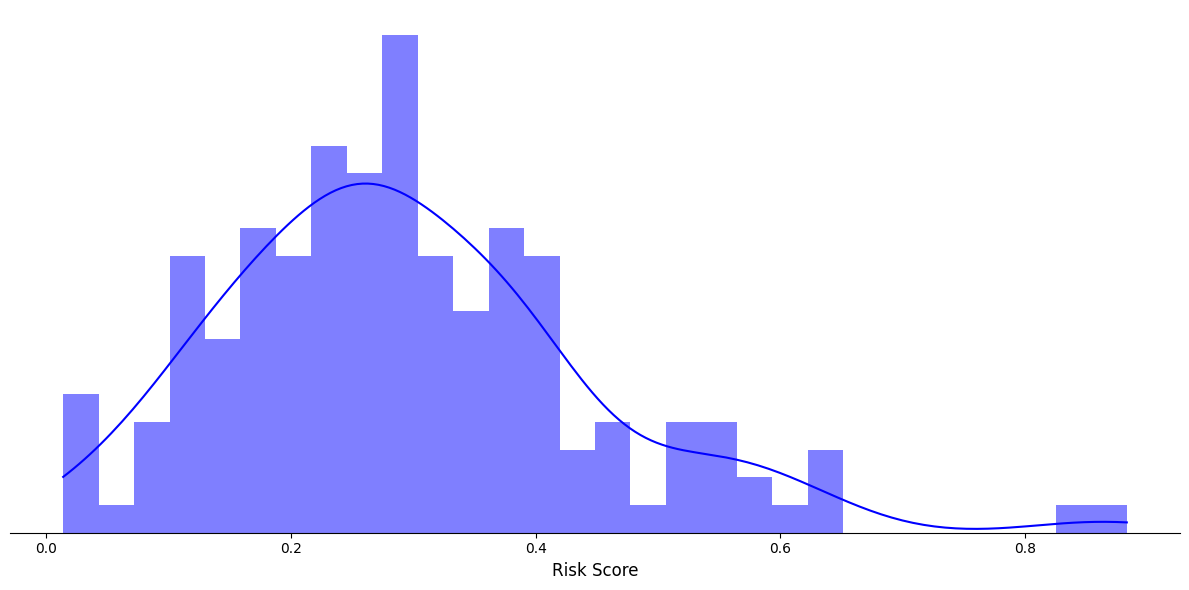

In [24]:
plt.figure(figsize=(12, 6))
sns.histplot(
    agg['risk_score'], 
    bins=30, 
    kde=True, 
    color='blue',
    edgecolor=None
)
# Quitar título y eje Y
plt.title('')
plt.ylabel('')
plt.yticks([])
# Ajustar eje X
plt.xlabel('Risk Score', fontsize=12)
sns.despine(left=True)  
plt.grid(False)

plt.tight_layout()
plt.show()

En general, se distingue un comportamiento esperado en donde la mayoría de observaciones se concentran en valores de riesgo medio-bajo (0.2-0.3), lo cual es típico en análisis urbanos. Por otro lado, es razonable la cantidad de observaciones que sobrepasan el umbral del 0.4, ya que es de esperarse que esas zonas más peligrosas sean casos excepcionales.

Sin embargo, del gráfico anterior se distingue una cola derecha excesivamente larga pero por unas pocas observaciones. Cuando las investigamos más a fondo nos damos cuenta que son zonas que su densidad es muy muy alta. Analizando sus códigos postales (19102, 19103, 19107), nos damos cuenta que corresponde a zonas dentro del centro de la ciudad. A simple vista, estas observaciones se puede clasificar como outliers. 

Si analizamos el resto de variables que componen el índice, tanto el rate por capita como por área, muestran valores excesivamente altos. Todo estos componentes se alinean para esos resultados en el score. 

In [25]:
agg[['ZCTA', 'risk_score', 'density_norm', 'capita_norm', 'area_norm', 'violent_norm']].sort_values(by='risk_score', ascending=False).head(4)

,ZCTA,risk_score,density_norm,capita_norm,area_norm,violent_norm
11,19102,0.883255,0.943191,1.000000,1.000000,0.278507
23,19107,0.844400,0.752591,1.000000,1.000000,0.210076
14,19103,0.645436,1.000000,0.450438,0.892269,0.169926
12,19102,0.635147,0.943191,0.585756,0.729190,0.222917


Haciendo un análisis de mayor profundidad tomando el código postal 1920 como ejemplo, se observa que los scores para esa misma localidad pero para momentos diferentes tienen considerablemente distintas métricas. 

In [27]:
agg[agg['ZCTA'] == 19102 ][['ZCTA', 'risk_score']]

,ZCTA,risk_score
11,19102,0.883255
12,19102,0.635147
13,19102,0.562597


Considerando que este es un problema de naturaleza espacial, la estrategia más apropiada para tratar los valores atípicos consiste en reemplazarlos por la media del score correspondiente a los tres períodos temporales del día. De esta manera se conserva la consistencia en el área postal evaluada.

Para implementar esta solución, el primer paso requiere crear una tabla temporal que contenga la media calculada por cada zona censal (ZCTA).

In [28]:
# Se hace agrupamiento
aggregate_grouped = agg.groupby(['ZCTA']).agg({
    'risk_score':'mean'
}).reset_index()

Ahora el siguiente paso es convertir en NA aquellas observaciones que sean outliers utilizando la regla del rango intercuantílico.

In [29]:
Q1 = agg['risk_score'].quantile(0.25)
Q3 = agg['risk_score'].quantile(0.75)
IQR = Q3 - Q1

# Definir límites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Reemplazar outliers por NaN
agg['risk_score_with_outliers'] = agg['risk_score']
agg['risk_score'] = agg['risk_score'].mask(
    (agg['risk_score'] < lower_bound) | (agg['risk_score'] > upper_bound),
    np.nan
)

Se cruzan las tablas utilizando como llave ZCTA. De esta manera se reemplaza aquellas observaciones que inicialmente habían sido catalogadas como outliers por el respectivo promedio de la zona ZCTA a la que pertenece.

In [30]:
# Unir agg con aggregate_grouped para tener el promedio de cada ZCTA
agg = agg.merge(
    aggregate_grouped,
    on='ZCTA',
    how='left',
    suffixes=('', '_mean')
)

# Reemplazar NaN en risk_score con el promedio de su ZCTA
agg['risk_score'] = agg['risk_score'].fillna(agg['risk_score_mean'])

# Eliminar columna auxiliar si ya no la necesitas
agg = agg.drop(columns=['risk_score_mean'])

Comparando la nueva distribución con la vieja:

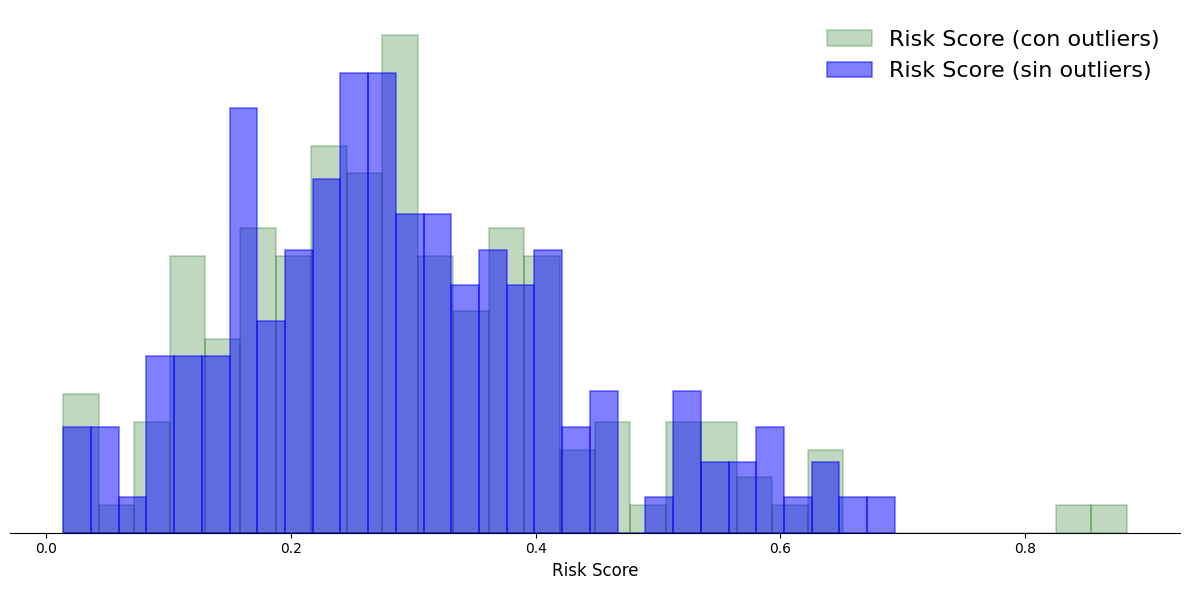

In [32]:
plt.figure(figsize=(12,6))

# Histograma 1: risk_score_with_outliers
plt.hist(
    agg['risk_score_with_outliers'], 
    bins=30,  
    alpha=0.25, 
    color="darkgreen", 
    edgecolor='darkgreen',
    linewidth=1.2,
    label="Risk Score (con outliers)",
    density=True 
)

# Histograma 2: risk_score
plt.hist(
    agg['risk_score'], 
    bins=30,  
    alpha=0.5, 
    color="blue", 
    edgecolor='blue',
    linewidth=1.2,
    label="Risk Score (sin outliers)",
    density=True  
)

plt.xlabel("Risk Score", fontsize=12)
plt.legend(frameon=False, fontsize=16, loc="upper right")
plt.ylabel('')
plt.yticks([])
sns.despine(left=True)  # mantener eje Y para mostrar densidad
plt.tight_layout()
plt.show()

La distribución es coherente con lo que esperaríamos tras eliminar outliers. Muestra una concentración clara de valores en el rango medio-bajo y una dispersión más moderada en los valores altos, sin que se contaminen los resultados por observaciones extremas.

Según lo mencionado anteriormente, más allá de calcular el score de riesgo, nuestro objetivo es asignar una etiqueta a aquellas zonas identificadas como altamente peligrosas. En la nueva distribución, destaca claramente la separación que presentan las áreas con un risk score superior a 0.5. Este comportamiento llama poderosamente la atención ya que se puede intuir que son observaciones que no se comportan como la mayoría. 

Precisamente, estas zonas son las que resultan de interés para el análisis por lo que para efectos de la clasificación se utilizará un umbral de 0.5 para asignar la etiqueta Bajo (Seguro) a las zonas con menor riesgo y Alto (Peligroso) a aquellas con mayor riesgo.

In [33]:
def categorize_std(p):
    if p <= 0.5:  
        return 'Low'
    else:
        return 'High'

agg['risk_level'] = agg['risk_score'].apply(categorize_std)
agg.head(3)

,ZCTA,time_of_day,crime_count,population,area_mile2,density_mile2,exposure_capita,exposure_area,rate_capita_post,rate_area_post,violent_share,capita_norm,area_norm,density_norm,violent_norm,risk_score,risk_score_with_outliers,risk_level
0,19004,Night,1,10668.0,2.725937,3913.517078,10668.0,2.725937,0.012178,149.730260,0.0,0.070912,0.052450,0.091019,0.0,0.056829,0.056829,Low
1,19012,Night,2,6699.0,1.748582,3831.103562,6699.0,1.748582,0.018142,214.609060,0.5,0.125229,0.088684,0.089102,0.5,0.163235,0.163235,Low
2,19027,Afternoon,1,19170.0,3.934618,4872.138000,19170.0,3.934618,0.007187,109.125636,0.0,0.025450,0.029772,0.113320,0.0,0.036326,0.036326,Low


Mediante esta técnica, ya se tiene un nivel de riesgo para cada zona ZCTA en cada uno de sus tres momentos del día. El siguiente paso es asignarle ese score de riesgo a cada uno de los crímenes reportados según su ZCTA y el momento del día:

In [35]:
# Se hace el merge para cada crimen usando como llaves la zona ZCTA y time_of_day
risk_cols = ['ZCTA','time_of_day','risk_score','risk_level']
df_with_risk = df_train.merge(agg[risk_cols], on=['ZCTA','time_of_day'], how='left')
df_with_risk[['ZCTA','time_of_day','risk_score','risk_level']].head(3)

,ZCTA,time_of_day,risk_score,risk_level
0,19104,Afternoon,0.385733,Low
1,19138,Afternoon,0.403961,Low
2,19140,Afternoon,0.528764,High


Ahora, si se grafica la distribución y analizamos la cantidad de zonas de riesgos identificadas en cada uno de los crímenes se pueden extraer las siguientes conclusiones:

- El desbalance es natural, no forzado.
- La mayoría de las ubicaciones caen en riesgo Moderado, lo cual se alinea con las distribuciones de crimen del mundo real (la mayoría de los lugares no son puntos críticos extremos o muy seguros). 
- Las áreas de alto riesgo son raras. Solo ~20% de los casos están en la categoría Alta — eso es realista porque los verdaderos puntos críticos de crimen son una minoría.
- La categoría de bajo riesgo también es menor que la moderada. Esto sugiere que las áreas genuinamente "seguras" son menos comunes que las "promedio", lo cual también es realista para un entorno urbano como Filadelfia.


In [36]:
df_with_risk['risk_level'].value_counts(normalize=True)

risk_level
Low     0.828645
High    0.171355
Name: proportion, dtype: float64

In [37]:
df_with_risk.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,median_income,mean_income,households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,39526,59711,19948,35.8,22.5,32.9,8.7,0.5465,0.385733,Low
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,51586,65880,12823,28.3,20.5,45.4,5.6,0.468,0.403961,Low
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,33149,51112,20557,39.7,26.8,29.9,3.6,0.517,0.528764,High


Se proceden a guardar la base de entrenamiento creada para efectos de trazabilidad de los datos.

In [ ]:
# df_with_risk.to_file("../Input/ModelingDatasets/Train/df_train_with_score.shp")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_16220\3263844908.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  df_with_risk.to_file("../Input/ModelingDatasets/Train/df_train_with_score.shp")
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field date create as date field, though DateTime requested.
  ogr_write(
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'crime_description' to 'crime_desc'
  ogr_write(
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'time_of_day' to 'time_of_da'
  ogr_write(
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'day_of_week' to 'day_of_wee'
  ogr_write(
C:\Users

## Cálculo en el conjunto de prueba

Ahora se debe construir el indicador de riesgo para el test. Cabe resaltar que esos datos fueron excluídos de la construcción del indicador para evitar data leakage en el conjunto de entrenamiento. 

Aún así, para efectos del cálculo en el conjunto de test se debe tomar toda la data disponible dado que es un índice de carácter retrospectivo.

**Testing Set**

Se crearan las siguientes funciones que se encargan de replicar el proceso que se hizo de manera más detallada en el conjunto de entrenamiento.

- variablesTemporales: crea variables como día, mes, momento del día, etc.
- variablesContextuales: clasifica el crimen en violento o no-violento
- variables demográficas: se encarga de hacer los cruces para calcular el área, población y densidad poblacional para cada ZCTA. 

In [ ]:
# Para este punto se recomienda nuevamente limpiar el enviroment y comenzar a ejecutar desde este bloque
df_train = cleanDataframe2(gpd.read_file("../Input/ModelingDatasets/Train/df_train_without_score_PointCoordinates.shp"))
df_test = cleanDataframe2(gpd.read_file("../Input/ModelingDatasets/Test/df_test_without_score_PointCoordinates.shp"))

# Se procede a hacer un merge ya que para el score en el test debe ser calculado tomando en cuenta toda la historia disponible
df_test_without_score = variablesDemograficas(variablesContextuales(variablesTemporales(pd.concat([df_train, df_test], ignore_index=True))))

Se crea la función cleanDataframe que se encarga de asignarle a cada columna el tipo de variable que le corresponde.

In [4]:
df_test_clean = cleanDataframe(data=df_test_without_score)
df_test_clean.head(3)

Filtered to rows with positive population and area. Shape: (218367, 31)


,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,latino_race_population,density_mile2,median_income,mean_income,households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,3640,17842.631594,39526,59711,19948,35.8,22.5,32.9,8.7,0.5465
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,938,18034.611223,51586,65880,12823,28.3,20.5,45.4,5.6,0.468
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,21674,16535.277352,33149,51112,20557,39.7,26.8,29.9,3.6,0.517


De manera análoga, se programa una función que se encarga de calcular el indicador de riesgo/score en donde se recibe como parámetro el dataframe incial al cual se le debe calcular el índice.

In [ ]:
test_results = apply_risk_indicator(df_test_clean)

Global per-capita rate: 0.126002139590385
Global per-area rate: 1198.9501126656003


c:\Users\Daniel Nunez\Documents\UCM\TFM\Trabajo-Final-Graduacion\Scripts\Funciones.py:446: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  violence_grp = df_new.groupby(['ZCTA','time_of_day']).apply(


Se procede a hacer el merge en donde a cada registro, se le asigna el nivel de riesgo que había en la zona al momento del crimen.

In [6]:
df_test_with_score = df_test_clean.merge(
    test_results[['ZCTA','time_of_day','risk_score','risk_level']],
    on=['ZCTA','time_of_day'], how='left'
)

In [7]:
df_test_with_score.head(3)

,dc_dist,psa,date,hour,crime_description,time_of_day,day_of_week,week_of_year,month,season,...,median_income,mean_income,households,household_25k_or_less,household_25k_to_50k,household_50k_to_150k,household_150k_or_more,GiniIndex,risk_score,risk_level
0,16,1,2023-12-31,19,Thefts,Afternoon,Sunday,52,December,winter,...,39526,59711,19948,35.8,22.5,32.9,8.7,0.5465,0.388458,Low
1,14,1,2023-12-31,19,Theft from Vehicle,Afternoon,Sunday,52,December,winter,...,51586,65880,12823,28.3,20.5,45.4,5.6,0.468,0.404926,Low
2,25,1,2023-12-31,19,Other Assaults,Afternoon,Sunday,52,December,winter,...,33149,51112,20557,39.7,26.8,29.9,3.6,0.517,0.527991,High


La distribución entre áreas de bajo y alto riesgo en el conjunto de test viene dada por:

In [8]:
df_test_with_score['risk_level'].value_counts(normalize=True)

risk_level
Low     0.837842
High    0.162158
Name: proportion, dtype: float64

Como se mencionó anteriormente, es fundamental considerar toda la información disponible al calcular el índice de criminalidad para el conjunto de test ya que si se utilizaran únicamente los datos de los primeros cinco meses de 2025, las medias poblacionales y los conteos de crímenes resultarían insuficientes, lo que subestimaría los valores reales del índice.

Por esta razón, se emplean todos los registros históricos para el cálculo del score, no obstante, dado que el período de evaluación se limita a los primeros cinco meses de 2025, posteriormente se filtra la información para considerar únicamente este intervalo temporal en el análisis de resultados.

In [9]:
df_test_with_score = df_test_with_score[(df_test_with_score['date'] >= '2025-01-01') & (df_test_with_score['date'] < '2025-06-01')]

Se procede a guardar los tres datasets en formatos .shp

In [ ]:
# Save as shapefile
# df_test_with_score.to_file("../Input/ModelingDatasets/Test/df_test_with_score.shp")

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_14940\3187813378.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  df_test_with_score.to_file("../Input/ModelingDatasets/Test/df_test_with_score.shp")
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Field date create as date field, though DateTime requested.
  ogr_write(
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'crime_description' to 'crime_desc'
  ogr_write(
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'time_of_day' to 'time_of_da'
  ogr_write(
C:\Users\Daniel Nunez\AppData\Roaming\Python\Python312\site-packages\pyogrio\raw.py:723: RuntimeWarning: Normalized/laundered field name: 'day_of_week' to 'day_of_wee'
  ogr_write(
C:\U

In [ ]:
# Conteo del % de eventos en el conjunto de test
df_test_with_score[(df_test_with_score['date'] >= '2025-01-01') & (df_test_with_score['date'] < '2025-06-01')]['risk_level'].value_counts(normalize=True)

risk_level
Low     0.837608
High    0.162392
Name: proportion, dtype: float64